# Read the input csv

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

file_name = 'intel_profile.csv'

In [137]:
df = pd.read_csv(file_name)
df.head(5)

,ID,Model Name,Device Name,Node Name,Status,Real Time (us),CPU Time (us),Node Type,Execution Type
0,6356587191312167706,Llama3PreAttnModel,GPU.0,Abs_10,EXECUTED,96,9,Abs,activation_opt__f16
1,6356587191312167706,Llama3PreAttnModel,GPU.0,Add_24,OPTIMIZED_OUT,0,0,Add,undef
2,6356587191312167706,Llama3PreAttnModel,GPU.0,Add_45,OPTIMIZED_OUT,0,0,Add,undef
3,6356587191312167706,Llama3PreAttnModel,GPU.0,Concat_36,EXECUTED,74,2,Concat,concatenation_gpu_simple_ref__f16
4,6356587191312167706,Llama3PreAttnModel,GPU.0,Concat_46,OPTIMIZED_OUT,0,0,Concat,undef


# An Overview Of Analysis

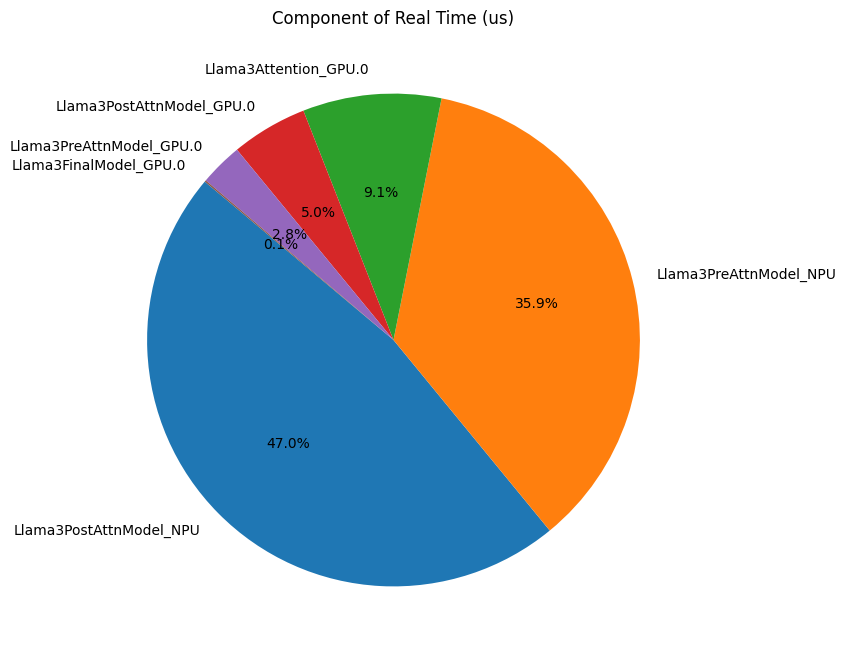

In [138]:
# Remove unnecessary columns
df_reduced = df.drop(columns=['Node Name', 'Status', 'Node Type', 'Execution Type'])

df_reduced['Name'] = df_reduced['Model Name'] + '_' + df_reduced['Device Name']

# Group by 'ID' and calculate the sum of 'Real Time (us)' and 'CPU Time (us)', while keeping 'Model Name' and 'Device Name'
df_grouped = df_reduced.groupby('Name', as_index=False).agg({
    'Model Name': 'first',
    'Device Name': 'first',
    'Real Time (us)': 'sum',
    'CPU Time (us)': 'sum'
})

# Sort the dataframe by 'Real Time (us)' in descending order
df_grouped_sorted = df_grouped.sort_values(by='Real Time (us)', ascending=False)

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(df_grouped_sorted['Real Time (us)'], labels=df_grouped_sorted['Name'], autopct='%1.1f%%', startangle=140)
plt.title('Component of Real Time (us)')
plt.show()


In [139]:
df_grouped_sorted

,Name,Model Name,Device Name,Real Time (us),CPU Time (us)
3,Llama3PostAttnModel_NPU,Llama3PostAttnModel,NPU,6057323,5074523
5,Llama3PreAttnModel_NPU,Llama3PreAttnModel,NPU,4628099,2623520
0,Llama3Attention_GPU.0,Llama3Attention,GPU.0,1169911,2571
2,Llama3PostAttnModel_GPU.0,Llama3PostAttnModel,GPU.0,643915,1484
4,Llama3PreAttnModel_GPU.0,Llama3PreAttnModel,GPU.0,364055,2308
1,Llama3FinalModel_GPU.0,Llama3FinalModel,GPU.0,13131,88


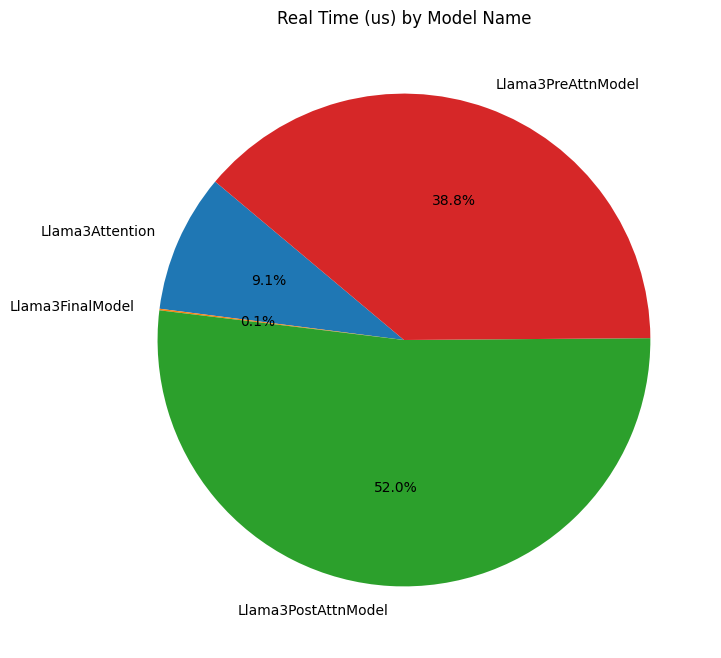

In [140]:
# Group by 'Model Name' and calculate the sum of 'Real Time (us)'
df_model_grouped = df.groupby('Model Name', as_index=False).agg({'Real Time (us)': 'sum'})

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(df_model_grouped['Real Time (us)'], labels=df_model_grouped['Model Name'], autopct='%1.1f%%', startangle=140)
plt.title('Real Time (us) by Model Name')
plt.show()

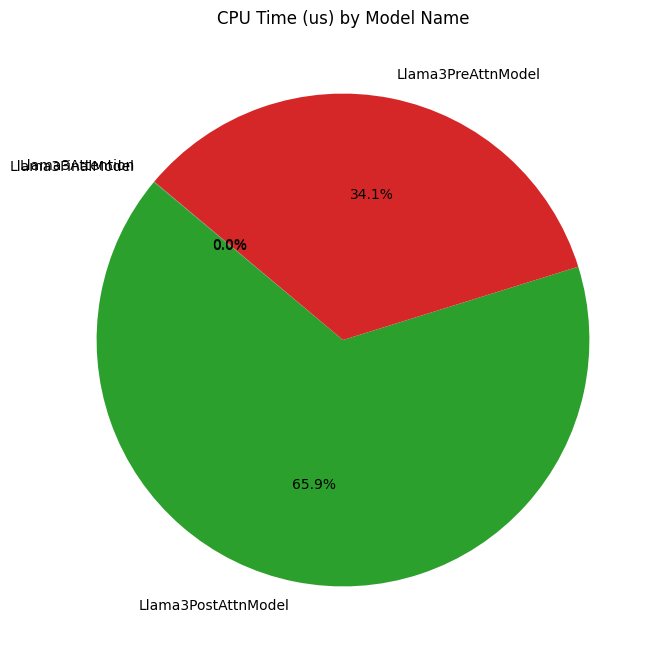

In [141]:
# Group by 'Model Name' and calculate the sum of 'CPU Time (us)'
df_model_grouped = df.groupby('Model Name', as_index=False).agg({'CPU Time (us)': 'sum'})

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(df_model_grouped['CPU Time (us)'], labels=df_model_grouped['Model Name'], autopct='%1.1f%%', startangle=140)
plt.title('CPU Time (us) by Model Name')
plt.show()

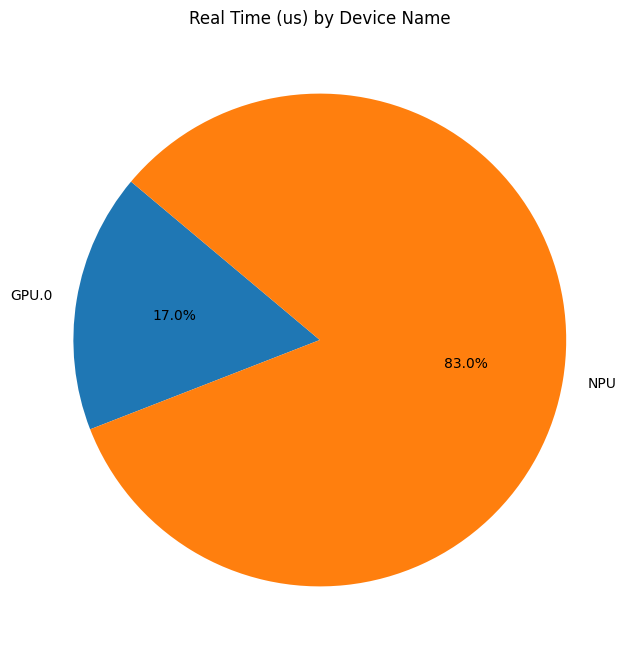

In [142]:
# Group by 'Device Name' and calculate the sum of 'Real Time (us)'
df_device_grouped = df.groupby('Device Name', as_index=False).agg({'Real Time (us)': 'sum'})

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(df_device_grouped['Real Time (us)'], labels=df_device_grouped['Device Name'], autopct='%1.1f%%', startangle=140)
plt.title('Real Time (us) by Device Name')
plt.show()

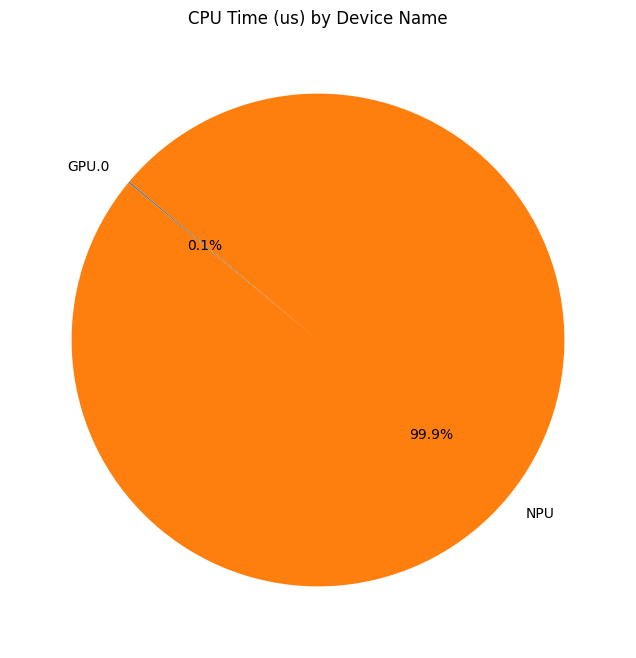

In [143]:
# Group by 'Device Name' and calculate the sum of 'CPU Time (us)'
df_device_grouped = df.groupby('Device Name', as_index=False).agg({'CPU Time (us)': 'sum'})

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(df_device_grouped['CPU Time (us)'], labels=df_device_grouped['Device Name'], autopct='%1.1f%%', startangle=140)
plt.title('CPU Time (us) by Device Name')
plt.show()

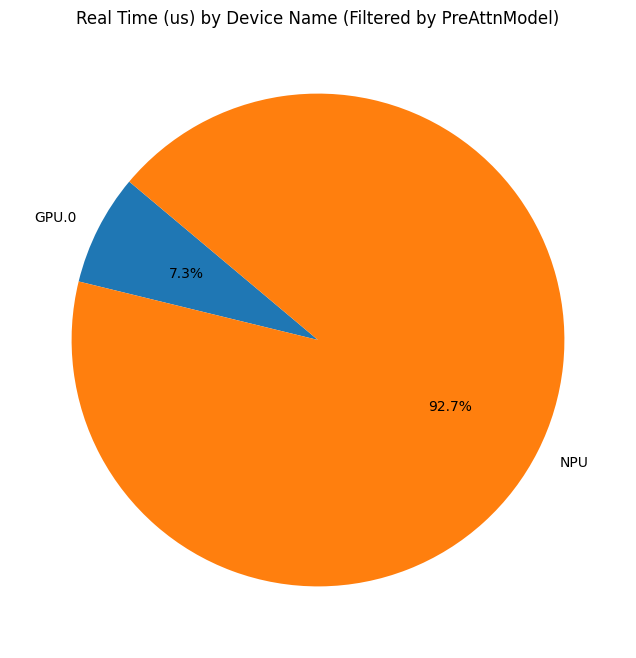

In [144]:
# Filter by Model Name containing "PreAttnModel"
filtered_df = df[df['Model Name'].str.contains('PreAttnModel')]

# Group by 'Device Name' and calculate the sum of 'Real Time (us)'
grouped_filtered_df = filtered_df.groupby('Device Name', as_index=False).agg({'Real Time (us)': 'sum'})

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(grouped_filtered_df['Real Time (us)'], labels=grouped_filtered_df['Device Name'], autopct='%1.1f%%', startangle=140)
plt.title('Real Time (us) by Device Name (Filtered by PreAttnModel)')
plt.show()

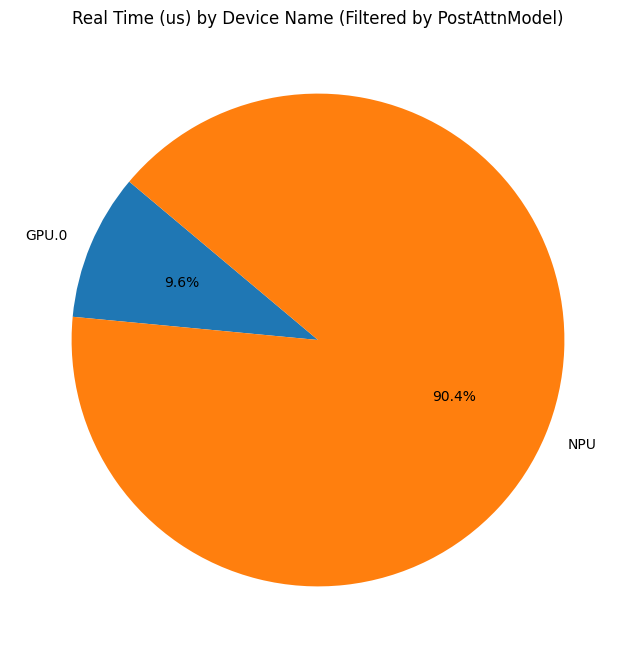

In [145]:
# Filter by Model Name containing "PostAttnModel"
filtered_df = df[df['Model Name'].str.contains('PostAttnModel')]

# Group by 'Device Name' and calculate the sum of 'Real Time (us)'
grouped_filtered_df = filtered_df.groupby('Device Name', as_index=False).agg({'Real Time (us)': 'sum'})

# Plot a pie chart
plt.figure(figsize=(10, 8))
plt.pie(grouped_filtered_df['Real Time (us)'], labels=grouped_filtered_df['Device Name'], autopct='%1.1f%%', startangle=140)
plt.title('Real Time (us) by Device Name (Filtered by PostAttnModel)')
plt.show()

# Analysis of NPU PreAttnModel

In [146]:
def plot_kernel_pie_chart(df):
    # Group by 'Node Name' and calculate the sum of 'Real Time (us)'
    df['Node Name'] = df['Node Name'].str.split('_').str[0]
    df_node_grouped = df.groupby('Node Name', as_index=False).agg({'Real Time (us)': 'sum'})
    # Sort the dataframe by 'Real Time (us)' in descending order
    df_node_grouped = df_node_grouped.sort_values(by='Real Time (us)', ascending=False)

    # Plot a pie chart
    plt.figure(figsize=(12, 8))
    plt.pie(df_node_grouped['Real Time (us)'], labels=df_node_grouped['Node Name'], autopct='%1.1f%%', startangle=140)
    plt.title('Real Time (us) by Node Name')
    plt.show()

In [147]:

# Filter by Model Name containing "PreAttnModel" and Device Name "NPU"
filtered_df = df[(df['Model Name'].str.contains('PreAttnModel')) & (df['Device Name'] == 'NPU')]

# Display the filtered dataframe
filtered_df

,ID,Model Name,Device Name,Node Name,Status,Real Time (us),CPU Time (us),Node Type,Execution Type
60,16901558074777635652,Llama3PreAttnModel,NPU,Abs_129,EXECUTED,241,680,Abs,Shave
61,16901558074777635652,Llama3PreAttnModel,NPU,Split_170,EXECUTED,104,104,Split,DMA
62,16901558074777635652,Llama3PreAttnModel,NPU,ReduceMax_130,EXECUTED,1825,386,ReduceMax,DPU
63,16901558074777635652,Llama3PreAttnModel,NPU,Multiply_135,EXECUTED,2704,2389,Multiply,DPU
64,16901558074777635652,Llama3PreAttnModel,NPU,Divide_134,EXECUTED,153,97,Divide,Shave
...,...,...,...,...,...,...,...,...,...
5647,16640418542992744244,Llama3PreAttnModel,NPU,Multiply_611615,EXECUTED,16865,3059,Multiply,Shave
5648,16640418542992744244,Llama3PreAttnModel,NPU,Subtract_611617,EXECUTED,2271,195,Subtract,DPU
5649,16640418542992744244,Llama3PreAttnModel,NPU,Concat_611619,EXECUTED,33394,30148,Concat,DMA
5650,16640418542992744244,Llama3PreAttnModel,NPU,Multiply_611616,EXECUTED,1805,3004,Multiply,Shave


/tmp/ipykernel_156193/677250667.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Node Name'] = df['Node Name'].str.split('_').str[0]


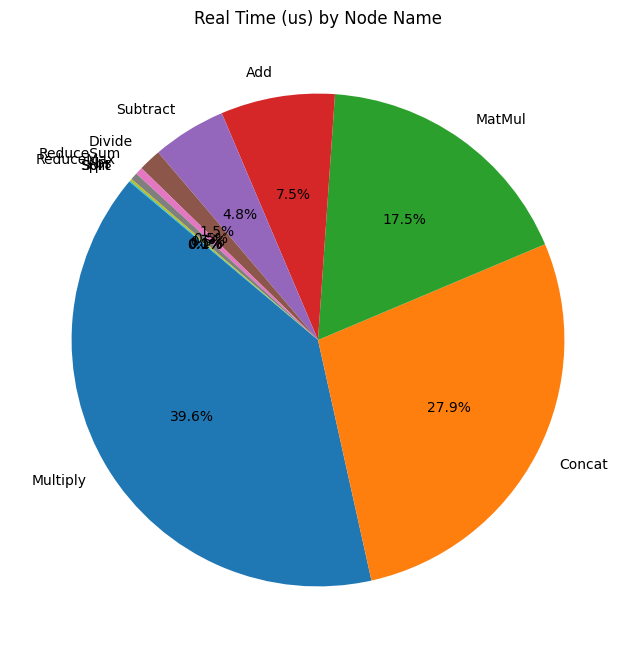

In [148]:
plot_kernel_pie_chart(filtered_df)

# Analysis of GPU PreAttnModel

In [149]:

# Filter by Model Name containing "PreAttnModel" and Device Name "NPU"
filtered_df = df[(df['Model Name'].str.contains('PreAttnModel')) & (df['Device Name'] == 'GPU.0')]

# Display the filtered dataframe
filtered_df

,ID,Model Name,Device Name,Node Name,Status,Real Time (us),CPU Time (us),Node Type,Execution Type
0,6356587191312167706,Llama3PreAttnModel,GPU.0,Abs_10,EXECUTED,96,9,Abs,activation_opt__f16
1,6356587191312167706,Llama3PreAttnModel,GPU.0,Add_24,OPTIMIZED_OUT,0,0,Add,undef
2,6356587191312167706,Llama3PreAttnModel,GPU.0,Add_45,OPTIMIZED_OUT,0,0,Add,undef
3,6356587191312167706,Llama3PreAttnModel,GPU.0,Concat_36,EXECUTED,74,2,Concat,concatenation_gpu_simple_ref__f16
4,6356587191312167706,Llama3PreAttnModel,GPU.0,Concat_46,OPTIMIZED_OUT,0,0,Concat,undef
...,...,...,...,...,...,...,...,...,...
5617,8388820160050391819,Llama3PreAttnModel,GPU.0,VariadicSplit_611473.out0,EXECUTED,53,3,VariadicSplit,generic_eltwise_ref__f16
5618,8388820160050391819,Llama3PreAttnModel,GPU.0,VariadicSplit_611473.out1,EXECUTED,14,3,Crop,generic_eltwise_ref__f16
5619,8388820160050391819,Llama3PreAttnModel,GPU.0,VariadicSplit_611473.out2,OPTIMIZED_OUT,0,0,Crop,undef
5620,8388820160050391819,Llama3PreAttnModel,GPU.0,VariadicSplit_611491.out0,EXECUTED,51,2,VariadicSplit,generic_eltwise_ref__f16


/tmp/ipykernel_156193/677250667.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Node Name'] = df['Node Name'].str.split('_').str[0]


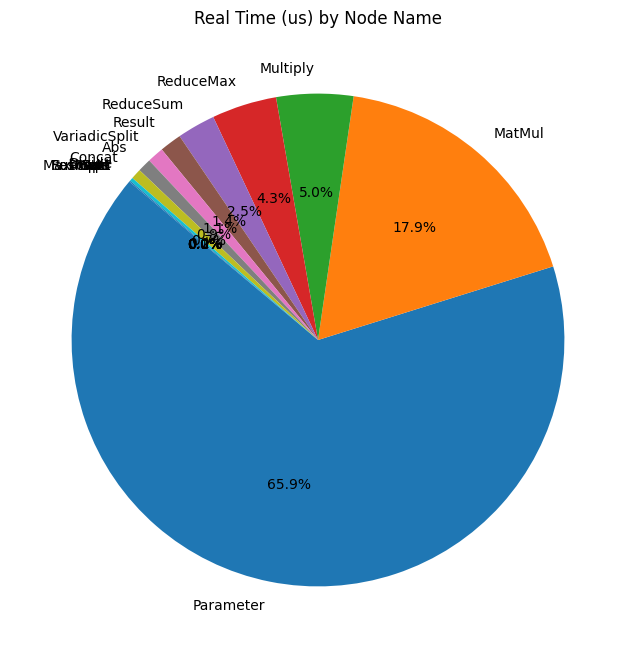

In [150]:
plot_kernel_pie_chart(filtered_df)

# Analysis of GPU AttnModel

In [151]:
# Filter by Model Name containing "PreAttnModel" and Device Name "NPU"
filtered_df = df[(df['Model Name'].str.contains('AttnModel')) & (df['Device Name'] == 'GPU.0')]

# Display the filtered dataframe
filtered_df

,ID,Model Name,Device Name,Node Name,Status,Real Time (us),CPU Time (us),Node Type,Execution Type
0,6356587191312167706,Llama3PreAttnModel,GPU.0,Abs_10,EXECUTED,96,9,Abs,activation_opt__f16
1,6356587191312167706,Llama3PreAttnModel,GPU.0,Add_24,OPTIMIZED_OUT,0,0,Add,undef
2,6356587191312167706,Llama3PreAttnModel,GPU.0,Add_45,OPTIMIZED_OUT,0,0,Add,undef
3,6356587191312167706,Llama3PreAttnModel,GPU.0,Concat_36,EXECUTED,74,2,Concat,concatenation_gpu_simple_ref__f16
4,6356587191312167706,Llama3PreAttnModel,GPU.0,Concat_46,OPTIMIZED_OUT,0,0,Concat,undef
...,...,...,...,...,...,...,...,...,...
5743,13322929598141692275,Llama3PostAttnModel,GPU.0,ReduceSum_611689/reshape_begin,OPTIMIZED_OUT,0,0,Reshape,undef
5744,13322929598141692275,Llama3PostAttnModel,GPU.0,ReduceSum_611689/reshape_begin_reorder,OPTIMIZED_OUT,0,0,Reorder,undef
5745,13322929598141692275,Llama3PostAttnModel,GPU.0,ReduceSum_611689_reorder,OPTIMIZED_OUT,0,0,Reorder,undef
5746,13322929598141692275,Llama3PostAttnModel,GPU.0,Result_611706,OPTIMIZED_OUT,0,0,Result,undef


/tmp/ipykernel_156193/677250667.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Node Name'] = df['Node Name'].str.split('_').str[0]


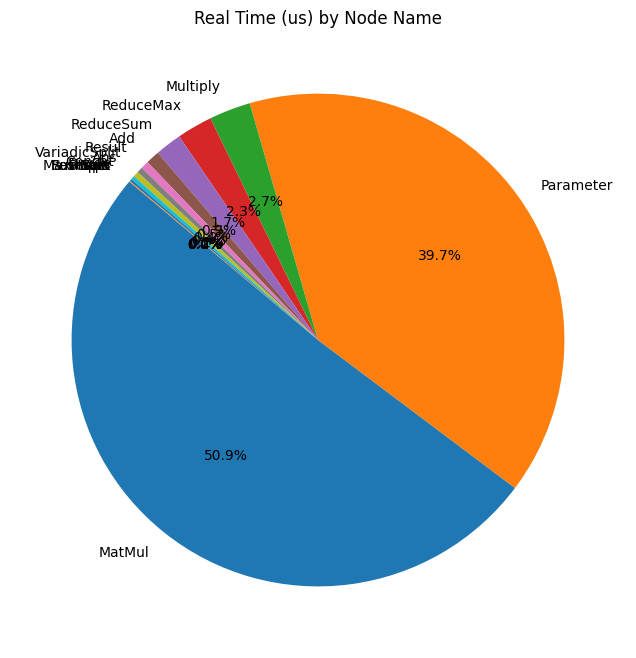

In [152]:
plot_kernel_pie_chart(filtered_df)

# Analysis of NPU PostAttnModel

In [153]:
# Filter by Model Name containing "PreAttnModel" and Device Name "NPU"
filtered_df = df[(df['Model Name'].str.contains('PostAttnModel')) & (df['Device Name'] == 'NPU')]

# Display the filtered dataframe
filtered_df

,ID,Model Name,Device Name,Node Name,Status,Real Time (us),CPU Time (us),Node Type,Execution Type
186,14309806641857130109,Llama3PostAttnModel,NPU,MatMul_236,EXECUTED,2711,5305,MatMul,DPU
187,14309806641857130109,Llama3PostAttnModel,NPU,Add_237,EXECUTED,105637,930,Add,DPU
188,14309806641857130109,Llama3PostAttnModel,NPU,Multiply_245,EXECUTED,1957,2540,Multiply,DPU
189,14309806641857130109,Llama3PostAttnModel,NPU,Multiply_251,EXECUTED,1960,12,Multiply,DPU
190,14309806641857130109,Llama3PostAttnModel,NPU,Abs_239,EXECUTED,451,715,Abs,Shave
...,...,...,...,...,...,...,...,...,...
5763,14189497464209798820,Llama3PostAttnModel,NPU,MatMul_611700,EXECUTED,6548,13561,MatMul,DPU
5764,14189497464209798820,Llama3PostAttnModel,NPU,Multiply_611702,EXECUTED,967,1846,Swish,Shave
5765,14189497464209798820,Llama3PostAttnModel,NPU,Multiply_611703,EXECUTED,1121,2438,Multiply,Shave
5766,14189497464209798820,Llama3PostAttnModel,NPU,MatMul_611704,EXECUTED,54608,92569,MatMul,DPU


/tmp/ipykernel_156193/677250667.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Node Name'] = df['Node Name'].str.split('_').str[0]


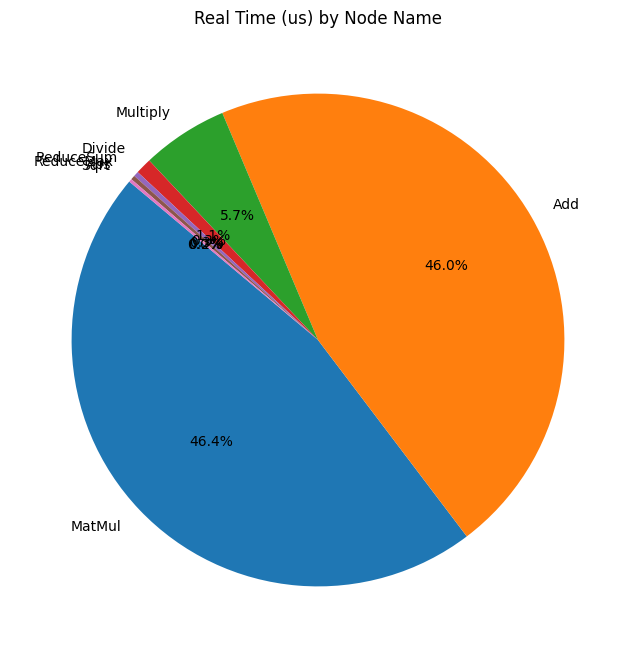

In [154]:
plot_kernel_pie_chart(filtered_df)

# Analysis of GPU PostAttnModel

In [155]:
# Filter by Model Name containing "PreAttnModel" and Device Name "NPU"
filtered_df = df[(df['Model Name'].str.contains('PostAttnModel')) & (df['Device Name'] == 'GPU.0')]

# Display the filtered dataframe
filtered_df

,ID,Model Name,Device Name,Node Name,Status,Real Time (us),CPU Time (us),Node Type,Execution Type
148,2497911740097465337,Llama3PostAttnModel,GPU.0,Abs_239,EXECUTED,14,3,Abs,activation_opt__f16
149,2497911740097465337,Llama3PostAttnModel,GPU.0,Add_237,EXECUTED,166,4,Add,eltwise_simple_vload8__f16
150,2497911740097465337,Llama3PostAttnModel,GPU.0,Add_253,OPTIMIZED_OUT,0,0,Add,undef
151,2497911740097465337,Llama3PostAttnModel,GPU.0,Add_263,EXECUTED,168,2,Add,eltwise_simple_vload8__f16
152,2497911740097465337,Llama3PostAttnModel,GPU.0,Divide_244,OPTIMIZED_OUT,0,0,Power,undef
...,...,...,...,...,...,...,...,...,...
5743,13322929598141692275,Llama3PostAttnModel,GPU.0,ReduceSum_611689/reshape_begin,OPTIMIZED_OUT,0,0,Reshape,undef
5744,13322929598141692275,Llama3PostAttnModel,GPU.0,ReduceSum_611689/reshape_begin_reorder,OPTIMIZED_OUT,0,0,Reorder,undef
5745,13322929598141692275,Llama3PostAttnModel,GPU.0,ReduceSum_611689_reorder,OPTIMIZED_OUT,0,0,Reorder,undef
5746,13322929598141692275,Llama3PostAttnModel,GPU.0,Result_611706,OPTIMIZED_OUT,0,0,Result,undef


/tmp/ipykernel_156193/677250667.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Node Name'] = df['Node Name'].str.split('_').str[0]


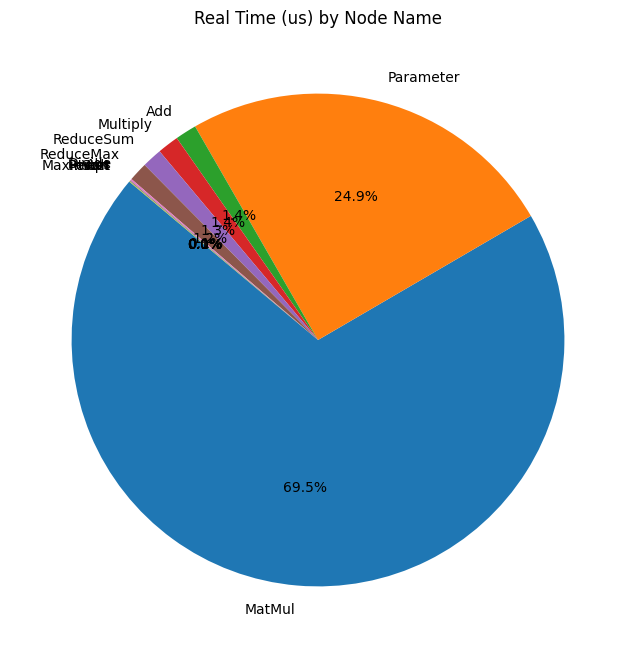

In [156]:
plot_kernel_pie_chart(filtered_df)

# Analysis of Comparative Advantage

In [157]:
df_filtered = df
df_filtered['Node Name'] = df_filtered['Node Name'].str.split('_').str[0]
df_grouped = df_filtered.groupby(['Node Name', 'Device Name'], as_index=False).agg({
    'Real Time (us)': 'sum',
    'CPU Time (us)': 'sum'
})
df_gpu = df_grouped[df_grouped['Device Name'] == 'GPU.0']
df_npu = df_grouped[df_grouped['Device Name'] == 'NPU']

def add_proportion_column(df):
    # Calculate the proportion of 'Real Time (us)' for each row
    total_real_time = df['Real Time (us)'].sum()
    df['Proportion'] = df['Real Time (us)'] / total_real_time
    total_cpu_time = df['CPU Time (us)'].sum()
    df['CPU Proportion'] = df['CPU Time (us)'] / total_cpu_time
    return df

df_gpu = add_proportion_column(df_gpu).set_index('Node Name')
df_npu = add_proportion_column(df_npu).set_index('Node Name')

/tmp/ipykernel_156193/768312152.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Proportion'] = df['Real Time (us)'] / total_real_time
/tmp/ipykernel_156193/768312152.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CPU Proportion'] = df['CPU Time (us)'] / total_cpu_time
/tmp/ipykernel_156193/768312152.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

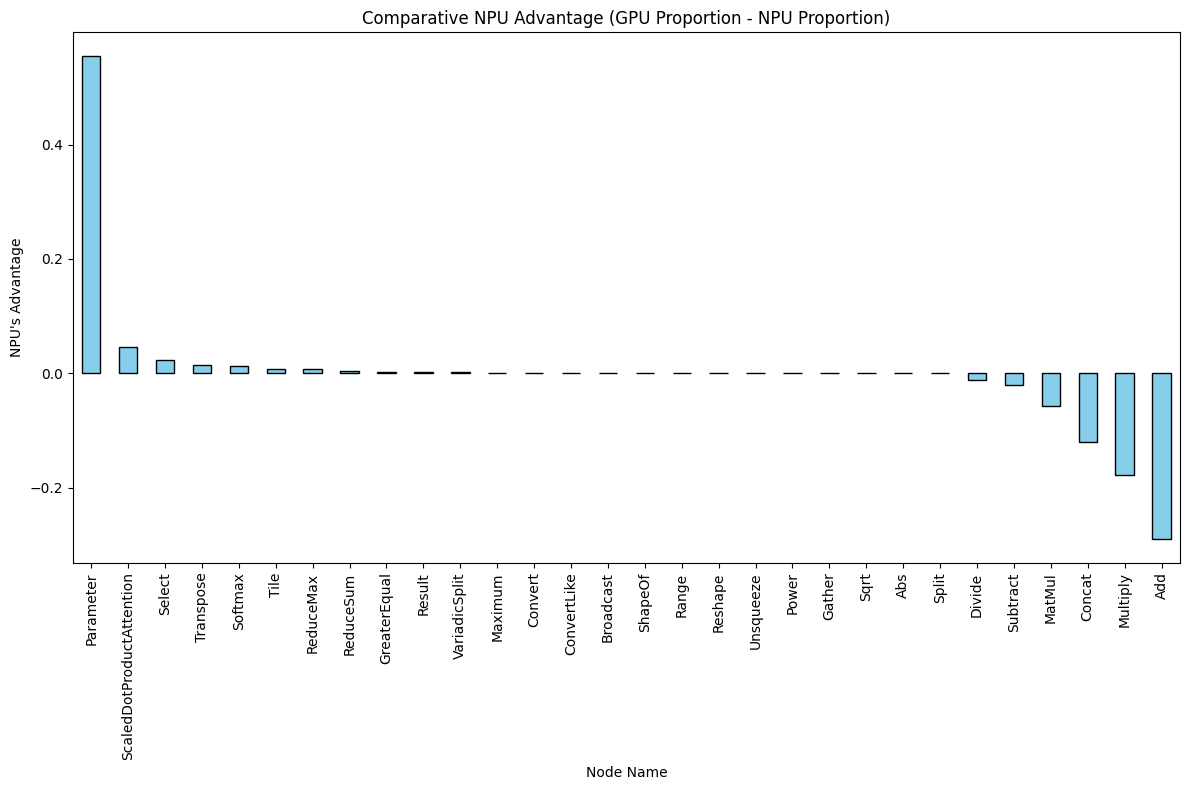

,NPU Proportion,GPU Proportion,Advantage
Node Name,,,
Parameter,0.000000,0.554070,0.554070
ScaledDotProductAttention,0.000000,0.046210,0.046210
Select,0.000000,0.023574,0.023574
Transpose,0.000000,0.014470,0.014470
Softmax,0.000000,0.012230,0.012230
Tile,0.000000,0.008125,0.008125
ReduceMax,0.003616,0.010755,0.007139
ReduceSum,0.003992,0.008015,0.004022
GreaterEqual,0.000000,0.002898,0.002898


In [158]:
cmp_df = pd.merge(
    df_npu[['Proportion']].rename(columns={'Proportion': 'NPU Proportion'}),
    df_gpu[['Proportion']].rename(columns={'Proportion': 'GPU Proportion'}),
    left_index=True,
    right_index=True,
    how='outer' 
).fillna(0)
# Calculate the difference between GPU Proportion and NPU Proportion
cmp_df['Advantage'] = cmp_df['GPU Proportion'] - cmp_df['NPU Proportion']

# Sort the dataframe by the 'Advantage' column
cmp_df_sorted = cmp_df.sort_values(by='Advantage', ascending=False)

# Plot a bar chart to show the comparative advantage
plt.figure(figsize=(12, 8))
cmp_df_sorted['Advantage'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Comparative NPU Advantage (GPU Proportion - NPU Proportion)')
plt.xlabel('Node Name')
plt.ylabel('NPU\'s Advantage')
plt.xticks(ticks=range(len(cmp_df_sorted.index)), labels=cmp_df_sorted.index, rotation=90)
plt.tight_layout()
plt.show()

cmp_df_sorted
